In [6]:
#Data Collection
import pandas as pd
import numpy as np

In [7]:
#Load the data set 
df = pd.read_csv('telecom_churn_starlink.csv')

In [8]:
print (df.head())

  CustomerID LocationType CurrentISP  MonthlyInternetSpeed  MonthlyDataUsage  \
0   CUST0001        Urban     Dialog                  38.3             110.8   
1   CUST0002        Rural     Dialog                  28.1              63.5   
2   CUST0003        Rural    Mobitel                  18.9             133.7   
3   CUST0004        Urban     Dialog                  29.6              16.3   
4   CUST0005        Urban     Dialog                  20.4             115.4   

   MonthlyBill ContractType  ComplaintFrequency  CustomerTenure  \
0       2646.0     Postpaid                   0              94   
1       3097.0     Postpaid                   0              55   
2       3772.0      Prepaid                   1              84   
3       3443.0      Prepaid                   0              58   
4       4048.0     Postpaid                   0              37   

   ServiceOutages StarlinkAwareness Churn  
0             0.3               Yes    No  
1             1.6           

In [9]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            2000 non-null   object 
 1   LocationType          2000 non-null   object 
 2   CurrentISP            2000 non-null   object 
 3   MonthlyInternetSpeed  2000 non-null   float64
 4   MonthlyDataUsage      2000 non-null   float64
 5   MonthlyBill           2000 non-null   float64
 6   ContractType          2000 non-null   object 
 7   ComplaintFrequency    2000 non-null   int64  
 8   CustomerTenure        2000 non-null   int64  
 9   ServiceOutages        2000 non-null   float64
 10  StarlinkAwareness     2000 non-null   object 
 11  Churn                 2000 non-null   object 
dtypes: float64(4), int64(2), object(6)
memory usage: 187.6+ KB
None


In [10]:
print (df.describe())

       MonthlyInternetSpeed  MonthlyDataUsage  MonthlyBill  \
count            2000.00000       2000.000000   2000.00000   
mean               24.84675        117.961400   3528.06800   
std                 9.98709         50.911944   1012.01752   
min                 1.00000          1.000000    500.00000   
25%                17.90000         82.675000   2857.75000   
50%                25.00000        117.400000   3512.00000   
75%                31.60000        153.950000   4204.75000   
max                57.40000        296.500000   6877.00000   

       ComplaintFrequency  CustomerTenure  ServiceOutages  
count         2000.000000       2000.0000     2000.000000  
mean             1.021500         60.6935        5.066100  
std              1.017622         34.5566        2.889991  
min              0.000000          1.0000        0.000000  
25%              0.000000         31.0000        3.000000  
50%              1.000000         61.0000        5.050000  
75%              2.00

In [11]:
print ("Missing Values:\n", df.isnull().sum())

Missing Values:
 CustomerID              0
LocationType            0
CurrentISP              0
MonthlyInternetSpeed    0
MonthlyDataUsage        0
MonthlyBill             0
ContractType            0
ComplaintFrequency      0
CustomerTenure          0
ServiceOutages          0
StarlinkAwareness       0
Churn                   0
dtype: int64


In [12]:
print ("Class Value:\n", df['Churn'].value_counts())

Class Value:
 Churn
No     1475
Yes     525
Name: count, dtype: int64


In [13]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

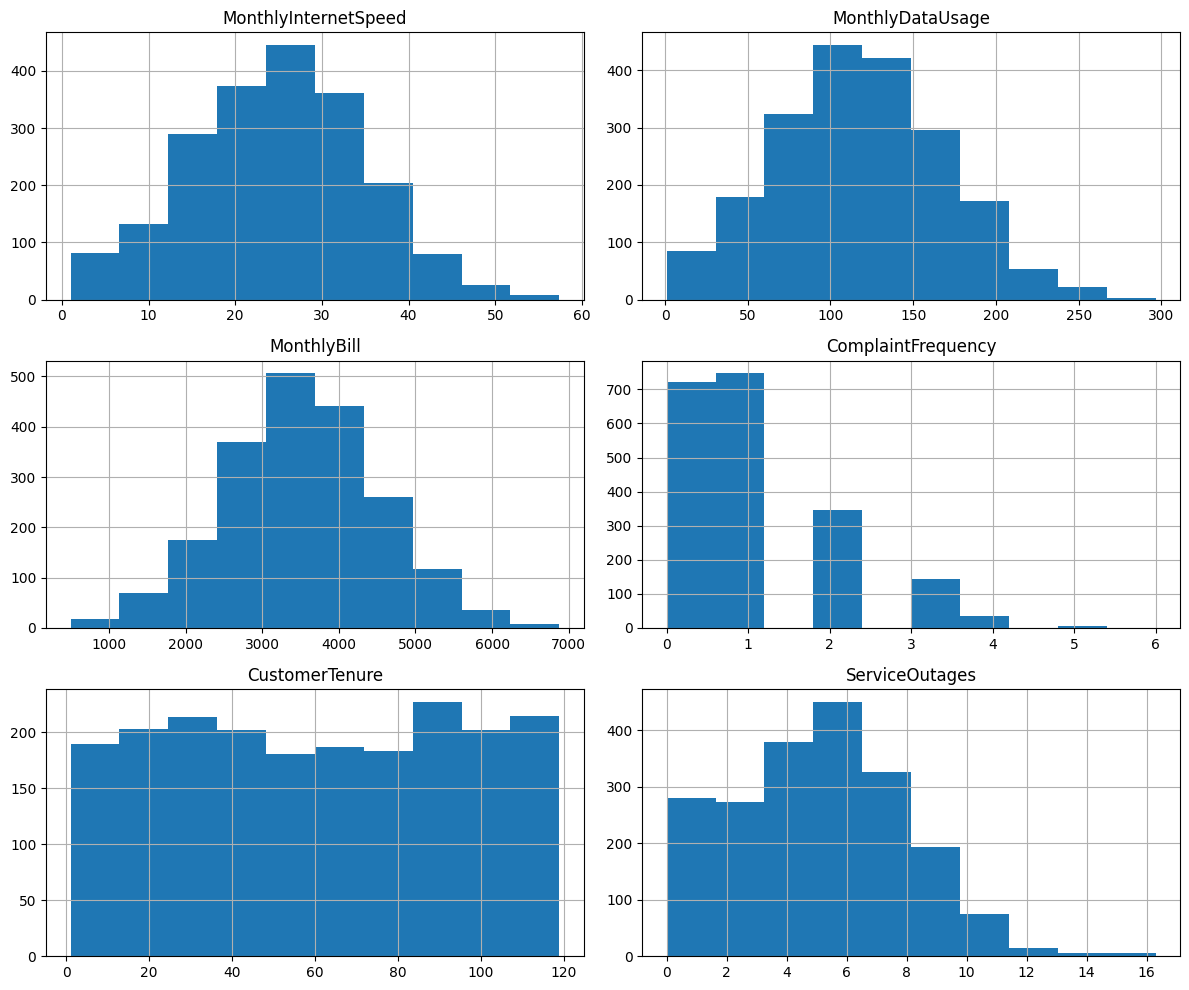

In [14]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()


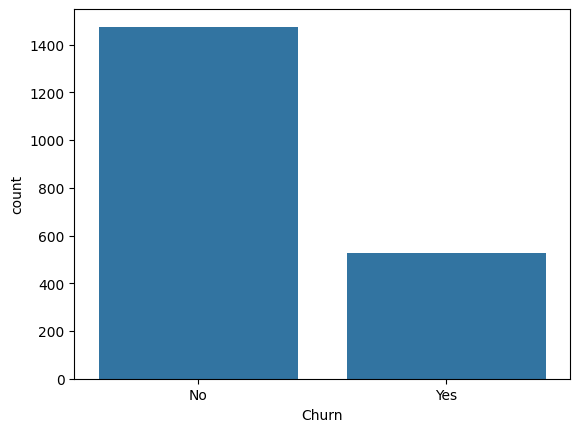

In [15]:
sns.countplot(x='Churn', data=df)
plt.show()

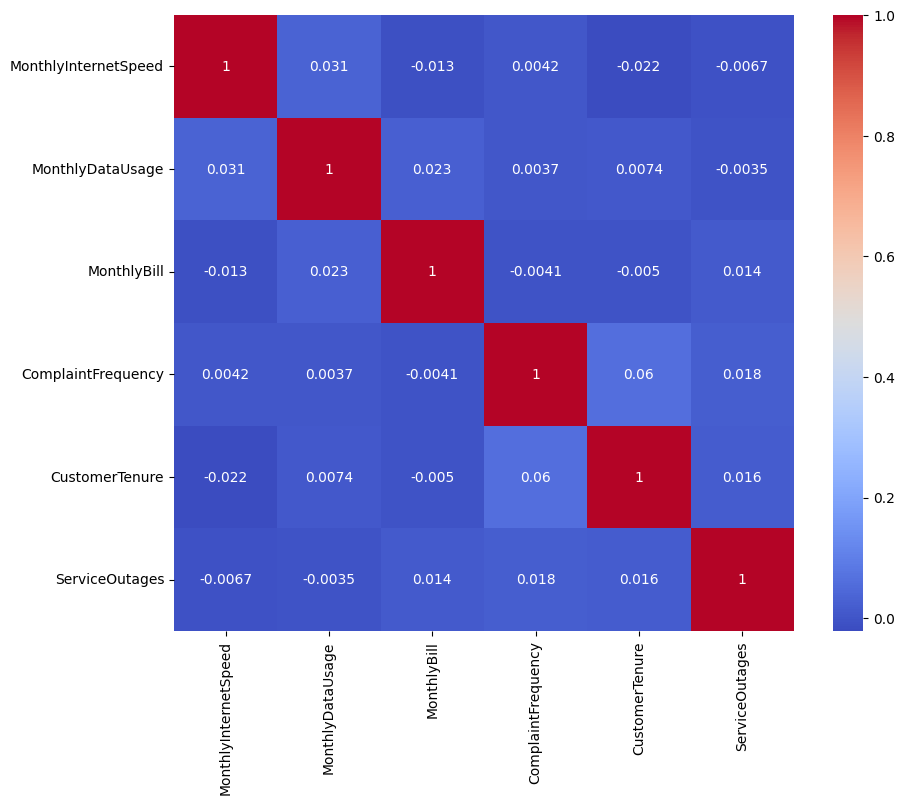

In [16]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=[np.number])  # Only numeric columns
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [17]:
#  Feature Engineering
df['NewCustomerFlag'] = (df['CustomerTenure'] < 12).astype(int)

In [18]:
print(df.columns)

Index(['CustomerID', 'LocationType', 'CurrentISP', 'MonthlyInternetSpeed',
       'MonthlyDataUsage', 'MonthlyBill', 'ContractType', 'ComplaintFrequency',
       'CustomerTenure', 'ServiceOutages', 'StarlinkAwareness', 'Churn',
       'NewCustomerFlag'],
      dtype='object')


In [19]:
# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [20]:
# Encode categorical variables
for col in df.select_dtypes(include='object').columns:
    if col != 'Churn':
        df[col] = LabelEncoder().fit_transform(df[col])

In [21]:
# Encode target variable
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

In [22]:
# Handle missing values (fill with median)
df.fillna(df.median(), inplace=True)

In [23]:

# Remove irrelevant columns (example: customerID)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

In [24]:
# Scale numerical features
scaler = StandardScaler()
num_cols = df.select_dtypes(include=np.number).columns.drop('Churn')
df[num_cols] = scaler.fit_transform(df[num_cols])

In [25]:
# Split the data
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [26]:
# Model Training
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [29]:
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Store metrics
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }
    
    # Display results
    print("="*50)
    print(f"{name} Results")
    print("="*50)
    
    # Display metrics in a table format
    metrics_df = pd.DataFrame(results[name], index=["Score"]).T
    print(metrics_df)
    
    # Display confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    print(cm_df)
    print("\n\n")

Logistic Regression Results
              Score
Accuracy   0.742500
Precision  0.550000
Recall     0.104762
F1-score   0.176000
ROC-AUC    0.537127

Confusion Matrix:
          Pred 0  Pred 1
Actual 0     286       9
Actual 1      94      11



Decision Tree Results
              Score
Accuracy   0.610000
Precision  0.289256
Recall     0.333333
F1-score   0.309735
ROC-AUC    0.520904

Confusion Matrix:
          Pred 0  Pred 1
Actual 0     209      86
Actual 1      70      35



Random Forest Results
              Score
Accuracy   0.742500
Precision  0.531250
Recall     0.161905
F1-score   0.248175
ROC-AUC    0.555529

Confusion Matrix:
          Pred 0  Pred 1
Actual 0     280      15
Actual 1      88      17



XGBoost Results
              Score
Accuracy   0.727500
Precision  0.467742
Recall     0.276190
F1-score   0.347305
ROC-AUC    0.582163

Confusion Matrix:
          Pred 0  Pred 1
Actual 0     262      33
Actual 1      76      29





c:\Users\kavis\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [12:52:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
